In [1]:
# 08 - Final ANCOVA Figures

#Objective:

#Create final presentation-ready figures for:

#1. Converter versus non-converter ANCOVA results.
#2. DLB versus Parkinson exploratory ANCOVA results.

#These figures are intended for the final presentation and project documentation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
PROJECT_ROOT = Path("..")

DATA_FILE = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

ANCOVA_DIR = PROJECT_ROOT / "results" / "ancova"
DLB_DIR = PROJECT_ROOT / "results" / "dlb_vs_pd"

FIGURES_DIR = PROJECT_ROOT / "figures" / "presentation" / "ancova"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Data exists:", DATA_FILE.exists())
print("ANCOVA dir exists:", ANCOVA_DIR.exists())
print("DLB dir exists:", DLB_DIR.exists())
print("Figures dir exists:", FIGURES_DIR.exists())

Data exists: True
ANCOVA dir exists: True
DLB dir exists: True
Figures dir exists: True


In [4]:
df = pd.read_csv(DATA_FILE)

df.shape

(97, 116)

In [5]:
df["conversion_status"].value_counts()

conversion_status
Non-converter    60
Converter        37
Name: count, dtype: int64

In [6]:
df["conversion_subtype"].value_counts()

conversion_subtype
Non-converter    60
DLB              20
PD                9
PD-MCI            8
Name: count, dtype: int64

In [7]:
ancova = pd.read_csv(
    ANCOVA_DIR / "repeated_measures_ancova_group_effects_fdr.csv"
)

ancova.head()

,effect,sum_sq,df,F,PR(>F),variable,p_fdr,significant_fdr
0,C(conversion_status),1.092981,1.0,0.510955,0.475367,density_sw,0.500387,False
1,C(conversion_status),30688.310905,1.0,0.981298,0.322800,total_N2_sw_count,0.358666,False
2,C(conversion_status),400792.622861,1.0,8.714675,0.003445,total_N3_sw_count,0.005742,True
3,C(conversion_status),653749.668285,1.0,5.905269,0.015773,total_sw_count,0.022533,True
4,C(conversion_status),0.001672,1.0,0.170645,0.679885,total_N2_sw_sec,0.679885,False


In [8]:
ancova.columns

Index(['effect', 'sum_sq', 'df', 'F', 'PR(>F)', 'variable', 'p_fdr',
       'significant_fdr'],
      dtype='object')

In [9]:
sig_ancova = ancova[
    ancova["PR(>F)"] < 0.05
].copy()

sig_ancova = sig_ancova.sort_values(
    "PR(>F)"
)

sig_ancova[
    [
        "variable",
        "F",
        "PR(>F)"
    ]
]

,variable,F,PR(>F)
7,total_trans_freq_Hz,61.540012,1.178927e-13
10,total_freq_Hz,55.283906,1.569863e-12
15,total_N3_trans_freq_Hz,44.546807,2.389366e-10
13,total_N3_freq_Hz,39.560547,1.964092e-09
14,total_N2_trans_freq_Hz,33.976490,1.672601e-08
12,total_N2_freq_Hz,32.795083,2.862416e-08
8,total_slope_min_max,31.798958,4.512262e-08
9,total_slope_0_min,17.433322,4.082499e-05
16,total_N2_slope_0_min,14.001085,2.255666e-04
19,total_N3_pkpk_amp_uV,9.786241,2.020753e-03


In [10]:
top_converter_vars = (
    sig_ancova
    .head(5)
    ["variable"]
    .tolist()
)

top_converter_vars

['total_trans_freq_Hz',
 'total_freq_Hz',
 'total_N3_trans_freq_Hz',
 'total_N3_freq_Hz',
 'total_N2_trans_freq_Hz']

In [11]:
regions = [
    "frontal",
    "central",
    "parietal",
    "occipital",
]

plot_df = df.copy()

for var in top_converter_vars:
    
    regional_cols = [
        f"{region}_{var}"
        for region in regions
        if f"{region}_{var}" in plot_df.columns
    ]
    
    print(var, regional_cols)
    
    plot_df[f"global_{var}"] = plot_df[
        regional_cols
    ].mean(axis=1)

total_trans_freq_Hz ['frontal_total_trans_freq_Hz', 'central_total_trans_freq_Hz', 'parietal_total_trans_freq_Hz', 'occipital_total_trans_freq_Hz']
total_freq_Hz ['frontal_total_freq_Hz', 'central_total_freq_Hz', 'parietal_total_freq_Hz', 'occipital_total_freq_Hz']
total_N3_trans_freq_Hz ['frontal_total_N3_trans_freq_Hz', 'central_total_N3_trans_freq_Hz', 'parietal_total_N3_trans_freq_Hz', 'occipital_total_N3_trans_freq_Hz']
total_N3_freq_Hz ['frontal_total_N3_freq_Hz', 'central_total_N3_freq_Hz', 'parietal_total_N3_freq_Hz', 'occipital_total_N3_freq_Hz']
total_N2_trans_freq_Hz ['frontal_total_N2_trans_freq_Hz', 'central_total_N2_trans_freq_Hz', 'parietal_total_N2_trans_freq_Hz', 'occipital_total_N2_trans_freq_Hz']


In [12]:
def plot_converter_histogram(data, variable, output_name):
    
    fig, ax = plt.subplots(figsize=(7, 5))
    
    non_converter = data.loc[
        data["conversion_status"] == "Non-converter",
        variable
    ].dropna()
    
    converter = data.loc[
        data["conversion_status"] == "Converter",
        variable
    ].dropna()
    
    ax.hist(
        non_converter,
        bins=15,
        alpha=0.65,
        label="Non-converters",
        color="#BDE0FE",
        edgecolor="#2D1238",
    )
    
    ax.hist(
        converter,
        bins=15,
        alpha=0.65,
        label="Converters",
        color="#FFE29A",
        edgecolor="#2D1238",
    )
    
    ax.axvline(
        non_converter.mean(),
        color="#2878B5",
        linestyle="--",
        linewidth=2,
        label="Non-converter mean",
    )
    
    ax.axvline(
        converter.mean(),
        color="#C27C00",
        linestyle="--",
        linewidth=2,
        label="Converter mean",
    )
    
    ax.set_title(
        variable.replace("global_", ""),
        fontweight="bold",
        color="#2D1238",
    )
    
    ax.set_xlabel("Value")
    ax.set_ylabel("Number of participants")
    ax.legend(frameon=False)
    
    plt.tight_layout()
    
    plt.savefig(
        FIGURES_DIR / output_name,
        dpi=300,
        bbox_inches="tight",
    )
    
    plt.show()

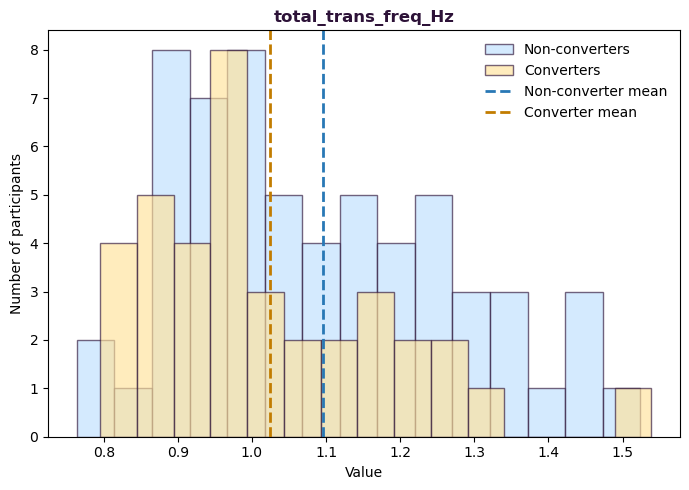

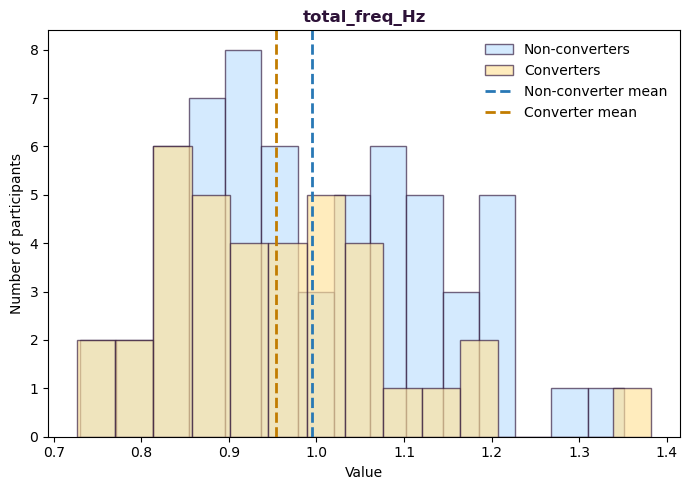

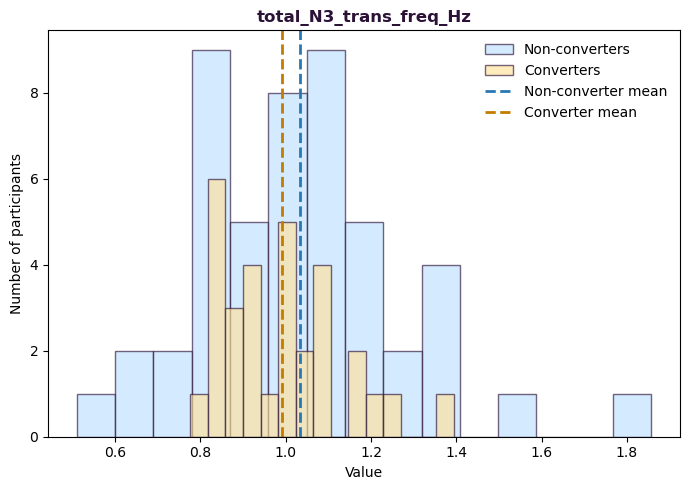

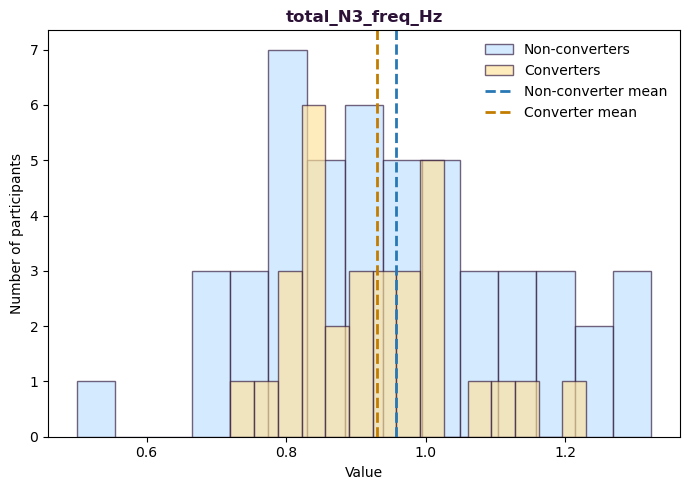

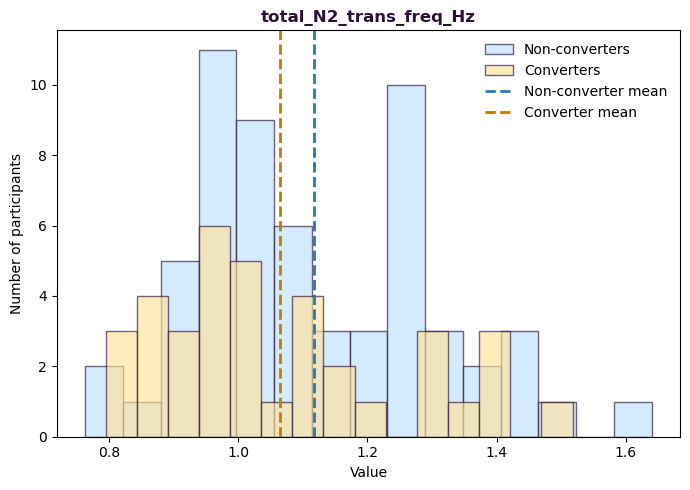

In [13]:
for var in top_converter_vars:
    
    global_var = f"global_{var}"
    
    plot_converter_histogram(
        plot_df,
        global_var,
        f"hist_converter_vs_nonconverter_{var}.png"
    )

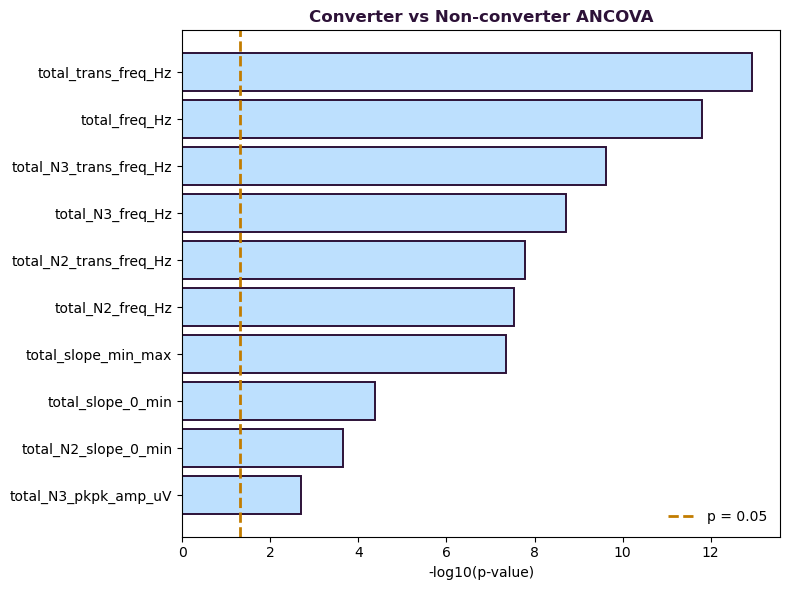

In [14]:
summary_df = sig_ancova.copy()

summary_df["minus_log10_p"] = -np.log10(
    summary_df["PR(>F)"]
)

summary_df = (
    summary_df
    .head(10)
    .sort_values("minus_log10_p")
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    summary_df["variable"],
    summary_df["minus_log10_p"],
    color="#BDE0FE",
    edgecolor="#2D1238",
    linewidth=1.4,
)

ax.axvline(
    -np.log10(0.05),
    linestyle="--",
    color="#C27C00",
    linewidth=2,
    label="p = 0.05",
)

ax.set_xlabel("-log10(p-value)")
ax.set_title(
    "Converter vs Non-converter ANCOVA",
    fontweight="bold",
    color="#2D1238",
)

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "summary_converter_vs_nonconverter_ancova.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [15]:
# on passe à la comparaison DLB vs PD


In [16]:
dlb_ancova = pd.read_csv(
    DLB_DIR / "ancova_dlb_vs_pd.csv"
)

dlb_ancova

,feature,F,p_value,q_value,significant
0,occipital_total_N3_pkpk_amp_uV,7.037708,0.014533,0.145331,False
1,occipital_total_N2_pkpk_amp_uV,2.773398,0.107405,0.537027,False
2,central_total_trans_freq_Hz,0.925439,0.343264,0.954530,False
3,central_total_freq_Hz,0.689116,0.412616,0.954530,False
4,frontal_total_slope_0_min,0.511308,0.479758,0.954530,False
5,central_total_N3_pkpk_amp_uV,0.169540,0.683771,0.954530,False
6,parietal_total_N2_freq_Hz,0.058008,0.811210,0.954530,False
7,parietal_total_sw_count,0.043772,0.835604,0.954530,False
8,occipital_total_slope_0_min,0.020616,0.886898,0.954530,False
9,frontal_total_sw_count,0.003302,0.954530,0.954530,False


In [17]:
dlb_df = df[
    df["conversion_subtype"] != "Non-converter"
].copy()

dlb_df["clinical_group"] = (
    dlb_df["conversion_subtype"]
    .replace({
        "PD": "Parkinson",
        "PD-MCI": "Parkinson",
        "DLB": "DLB",
    })
)

dlb_df["clinical_group"].value_counts()

clinical_group
DLB          20
Parkinson    17
Name: count, dtype: int64

In [18]:
dlb_features_to_plot = [
    "occipital_total_N3_pkpk_amp_uV",
    "occipital_total_N2_pkpk_amp_uV",
]

In [19]:
def plot_dlb_pd_histogram(data, variable, output_name):
    
    fig, ax = plt.subplots(figsize=(7, 5))
    
    dlb = data.loc[
        data["clinical_group"] == "DLB",
        variable
    ].dropna()
    
    parkinson = data.loc[
        data["clinical_group"] == "Parkinson",
        variable
    ].dropna()
    
    ax.hist(
        dlb,
        bins=10,
        alpha=0.65,
        label="DLB",
        color="#D7BDE2",
        edgecolor="#2D1238",
    )
    
    ax.hist(
        parkinson,
        bins=10,
        alpha=0.65,
        label="Parkinson",
        color="#A8E6CF",
        edgecolor="#2D1238",
    )
    
    ax.axvline(
        dlb.mean(),
        color="#7D3C98",
        linestyle="--",
        linewidth=2,
        label="DLB mean",
    )
    
    ax.axvline(
        parkinson.mean(),
        color="#2E8B57",
        linestyle="--",
        linewidth=2,
        label="Parkinson mean",
    )
    
    ax.set_title(
        variable,
        fontweight="bold",
        color="#2D1238",
    )
    
    ax.set_xlabel("Value")
    ax.set_ylabel("Number of participants")
    ax.legend(frameon=False)
    
    plt.tight_layout()
    
    plt.savefig(
        FIGURES_DIR / output_name,
        dpi=300,
        bbox_inches="tight",
    )
    
    plt.show()

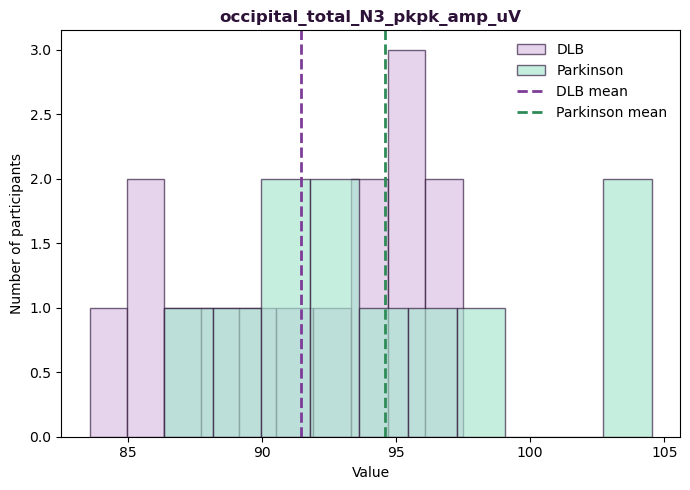

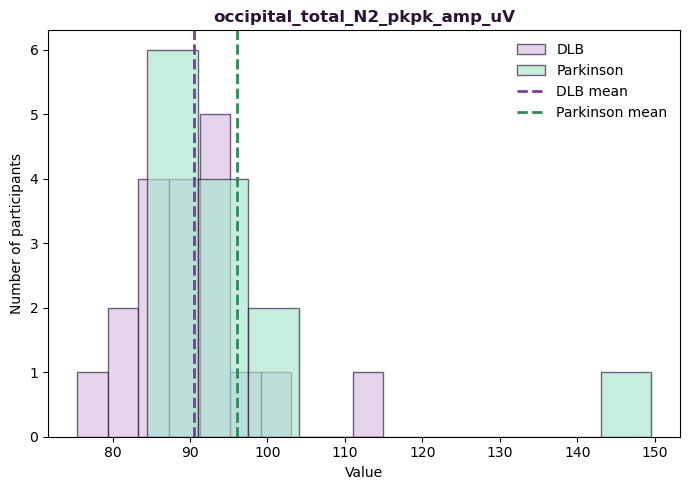

In [20]:
for feature in dlb_features_to_plot:
    
    plot_dlb_pd_histogram(
        dlb_df,
        feature,
        f"hist_dlb_vs_parkinson_{feature}.png"
    )

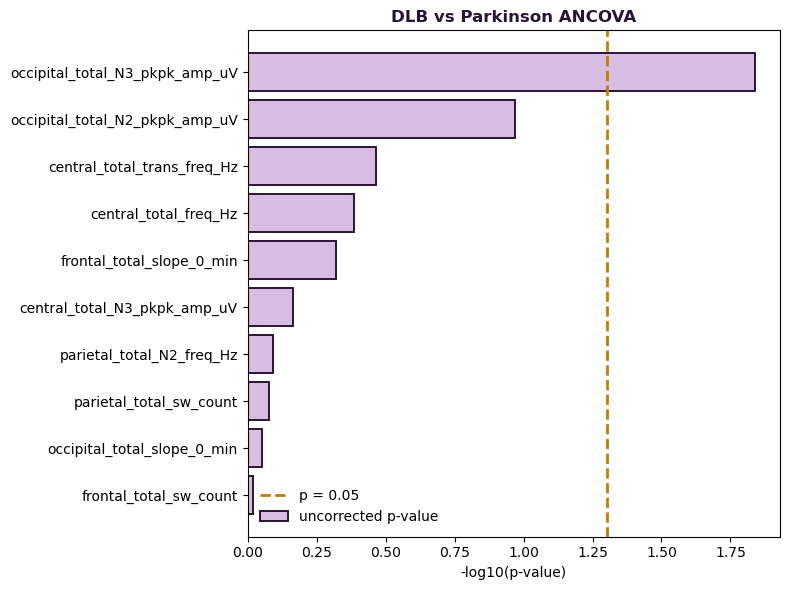

In [21]:
dlb_plot = dlb_ancova.copy()

dlb_plot["minus_log10_p"] = -np.log10(
    dlb_plot["p_value"]
)

dlb_plot["minus_log10_q"] = -np.log10(
    dlb_plot["q_value"]
)

dlb_plot = dlb_plot.sort_values(
    "minus_log10_p"
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    dlb_plot["feature"],
    dlb_plot["minus_log10_p"],
    color="#D7BDE2",
    edgecolor="#2D1238",
    linewidth=1.4,
    label="uncorrected p-value",
)

ax.axvline(
    -np.log10(0.05),
    linestyle="--",
    color="#C27C00",
    linewidth=2,
    label="p = 0.05",
)

ax.set_xlabel("-log10(p-value)")
ax.set_title(
    "DLB vs Parkinson ANCOVA",
    fontweight="bold",
    color="#2D1238",
)

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "summary_dlb_vs_parkinson_ancova.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()